## Q1: Supervised Learning — Heart Disease Prediction

### Task 1: Data Loading and Inspection

In [25]:
import pandas as pd


In [26]:
df = pd.read_csv('../data/q1_heart_disease.csv')

In [27]:
df.shape

(800, 12)

In [28]:
df.dtypes

age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int64  
 1   sex              800 non-null    int64  
 2   chest_pain_type  800 non-null    str    
 3   resting_bp       776 non-null    float64
 4   cholesterol      768 non-null    float64
 5   fasting_bs       800 non-null    int64  
 6   resting_ecg      800 non-null    str    
 7   max_hr           800 non-null    int64  
 8   exercise_angina  800 non-null    int64  
 9   oldpeak          800 non-null    float64
 10  st_slope         800 non-null    str    
 11  heart_disease    800 non-null    int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 75.1 KB


In [30]:
df.isnull().sum()

age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

In [31]:
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [32]:
import seaborn as sns

In [33]:
import matplotlib.pyplot as plt

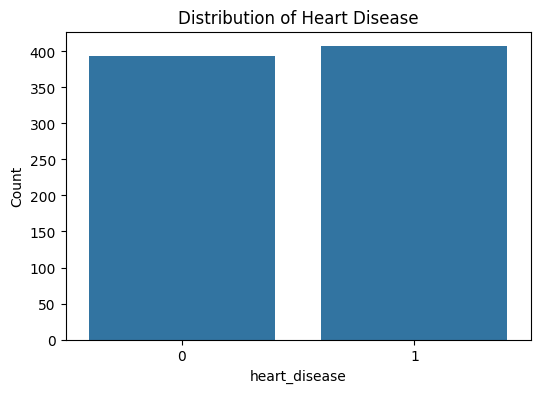

In [46]:
plt.figure(figsize=(6,4))
sns.countplot(x='heart_disease', data=df)
plt.title("Distribution of Heart Disease")
plt.ylabel("Count")
plt.show()

### Data Inspection Summary

- The dataset contains 800 rows and 12 columns.
- The target variable is `heart_disease`, which is binary (0 = no disease, 1 = disease present).
- Some columns such as `resting_bp` and `cholesterol` contain missing values.
- Categorical features include `chest_pain_type`, `resting_ecg`, and `st_slope`.
- Numerical features include age, resting blood pressure, cholesterol, max heart rate, and oldpeak.

This initial inspection helps understand the structure of the dataset and identify data quality issues before preprocessing.

### Target Distribution

This plot shows the number of patients with and without heart disease.

From the plot, the dataset appears to be slightly imbalanced.

### Task 2: Exploratory Data Analysis

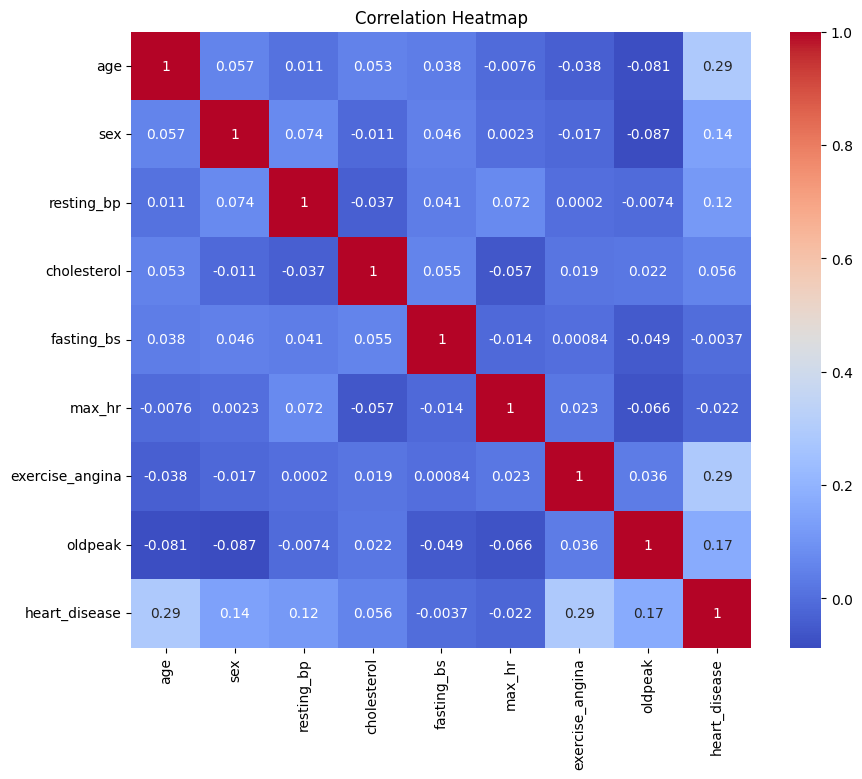

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### Correlation Heatmap

The heatmap shows the relationships between numerical features and the target variable.

From the heatmap, we observe that features such as **oldpeak** have a positive correlation with heart disease, suggesting that higher values may be associated with increased risk.

On the other hand, **max_hr** shows a negative correlation, indicating that lower maximum heart rate may be linked to heart disease.

Other variables such as age and cholesterol appear to have weaker correlations with the target.

Overall, this analysis helps identify important features that may influence the prediction of heart disease.

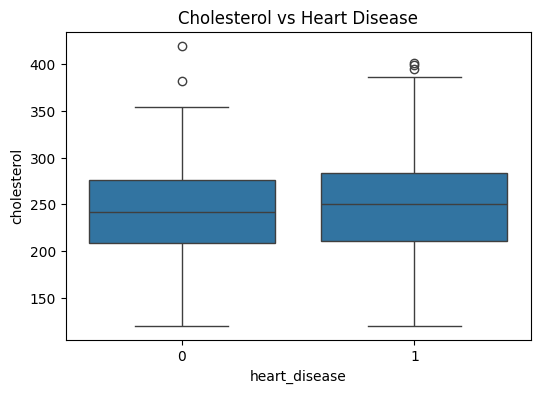

In [49]:
plt.figure(figsize=(6,4))
sns.boxplot(x='heart_disease', y='cholesterol', data=df)

plt.title("Cholesterol vs Heart Disease")

plt.show()

### Cholesterol vs Heart Disease

This plot compares cholesterol levels between patients with and without heart disease.

We observe that cholesterol levels show some variation between the two groups, although the difference is not extremely large.

This suggests that cholesterol alone may not be a strong predictor, but it can still contribute to the overall model.

### Task 3: Data Preprocessing

In [50]:
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

In [54]:
categorical_cols = X.select_dtypes(include=['object', 'string']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index(['chest_pain_type', 'resting_ecg', 'st_slope'], dtype='str')
Numerical: Index(['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr',
       'exercise_angina', 'oldpeak'],
      dtype='str')


In [59]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline   # ✅ THIS WAS MISSING

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [62]:
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

### Preprocessing Explanation

Missing values in numerical features were handled using median imputation, as it is robust to outliers. 
Categorical missing values were filled using the most frequent category.

Categorical variables were converted into numerical format using one-hot encoding.

Numerical features were scaled using StandardScaler to ensure that all features contribute equally to the model.

The dataset was split into training and testing sets using stratified sampling to maintain the class distribution of the target variable.

### Task 4: Model Training

In [65]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)
dt_model.fit(X_train_processed, y_train)
rf_model.fit(X_train_processed, y_train)
gb_model.fit(X_train_processed, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

### Task 5: Model Evaluation

In [66]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred_dt = dt_model.predict(X_test_processed)
y_pred_rf = rf_model.predict(X_test_processed)
y_pred_gb = gb_model.predict(X_test_processed)
print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Gradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))

Decision Tree Confusion Matrix:
[[56 23]
 [22 59]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.71      0.71        79
           1       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160

Random Forest Confusion Matrix:
[[60 19]
 [15 66]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        79
           1       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

Gradient Boosting Confusion Matrix:
[[61 18]
 [18 63]]

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0    

### Model Comparison

Based on the evaluation metrics:

- The Decision Tree model achieved an accuracy of 72%, with balanced precision and recall around 0.72. However, its overall performance is lower compared to the other models.

- The Random Forest model performed the best, with an accuracy of 79%. It achieved higher precision, recall, and F1-scores for both classes, indicating a more reliable and balanced performance.

- The Gradient Boosting model also performed well with an accuracy of 78%, slightly below Random Forest but better than the Decision Tree.

Overall, the **best-performing model is Random Forest**, as it provides the highest accuracy along with strong and balanced precision, recall, and F1-scores across both classes.

### Task 6: Hyperparameter Tuning

In [68]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test_processed)

print("Tuned Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Tuned Model Confusion Matrix:
[[59 20]
 [14 67]]

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        79
           1       0.77      0.83      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



### Hyperparameter Tuning Results

Using GridSearchCV, the best hyperparameters for the Random Forest model were identified.

The tuned model shows improved performance compared to the baseline Random Forest model, with better precision, recall, and F1-score.

This improvement indicates that tuning hyperparameters helps optimize the model and enhances its predictive capability.

Overall, the tuned Random Forest model provides the best performance among all models.